# Задача 2: Анализ тональности с помощью keras

**Цель**: научиться строить нейронную сеть для классификации текстов.

Этот ноутбук — **рабочий пример**, который вы берёте за основу и модифицируете.

---

### Что здесь есть

| Шаг | Описание |
|-----|----------|
| 1 | Данные: русскоязычные отзывы с метками |
| 2 | Превращаем тексты в числа (TF-IDF) |
| 3 | Строим и обучаем нейросеть на keras |
| 4 | Оцениваем качество (F1, Precision, Recall) |
| 5 | Графики обучения |

> **Уровень 1 (до 7 баллов)**: повторите этот пример со своими изменениями + напишите объяснение.
>
> **Уровень 2 (до 10 баллов)**: добавьте пункты из README (Dropout, мультиклассовость, сравнение архитектур и т.д.)

In [ ]:
#!pip install scikit-learn
#!pip install tensorflow

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, precision_score, recall_score

from tensorflow import keras
from tensorflow.keras import layers

## Шаг 1. Данные

40 отзывов: 15 позитивных, 15 негативных, 10 нейтральных.

Для базового примера используем **бинарную классификацию** (позитив / негатив).

In [2]:
sentiment_data = {
    "text": [
        # --- позитив (1) ---
        "Отличный фильм, очень понравился!",
        "Прекрасная книга, рекомендую всем прочитать.",
        "Качественный товар, доволен покупкой.",
        "Замечательный сервис, быстро и профессионально.",
        "Потрясающий ресторан, вкусная еда и уютная атмосфера.",
        "Великолепный спектакль, получил массу удовольствия.",
        "Отличное приложение, удобный интерфейс.",
        "Прекрасный отель, комфортные номера и хороший завтрак.",
        "Замечательный преподаватель, интересные лекции.",
        "Потрясающая музыка, слушаю постоянно.",
        "Отличный телефон, все работает быстро.",
        "Прекрасный подарок, очень доволен.",
        "Качественный кофе, ароматный и вкусный.",
        "Замечательный парк, красивая природа.",
        "Потрясающий концерт, незабываемые эмоции.",
        # --- негатив (0) ---
        "Ужасный фильм, полная потеря времени.",
        "Плохая книга, скучно и неинтересно.",
        "Низкое качество товара, очень разочарован.",
        "Плохой сервис, долго ждал и ничего не получил.",
        "Отвратительный ресторан, невкусная еда.",
        "Скучный спектакль, не рекомендую.",
        "Плохое приложение, постоянно глючит.",
        "Ужасный отель, грязные номера и плохое обслуживание.",
        "Скучный преподаватель, неинтересные лекции.",
        "Плохая музыка, не понравилась.",
        "Плохой телефон, постоянно зависает.",
        "Разочаровался в подарке, не то что ожидал.",
        "Плохой кофе, безвкусный и холодный.",
        "Запущенный парк, грязно и неухоженно.",
        "Скучный концерт, не оправдал ожиданий.",
        # --- нейтрал (2) ---
        "Обычный фильм, ничего особенного.",
        "Стандартная книга, читается нормально.",
        "Обычный товар, соответствует описанию.",
        "Нормальный сервис, без особых претензий.",
        "Обычный ресторан, стандартное меню.",
        "Средний спектакль, можно посмотреть.",
        "Обычное приложение, работает как надо.",
        "Стандартный отель, без изысков.",
        "Обычный преподаватель, стандартные лекции.",
        "Средняя музыка, ничего особенного.",
    ],
    "sentiment": [
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
    ]
}

df = pd.DataFrame(sentiment_data)

print(f"Всего отзывов: {len(df)}")
print(df["sentiment"].value_counts().sort_index().rename(
    {0: "негатив", 1: "позитив", 2: "нейтрал"}
))

Всего отзывов: 40
sentiment
негатив    15
позитив    15
нейтрал    10
Name: count, dtype: int64


## Шаг 2. Векторизация текстов (TF-IDF)

Нейросеть работает с числами, а не с текстом. **TF-IDF** превращает каждый текст в вектор чисел, где каждое число — «важность» конкретного слова.

```
"Отличный фильм"  →  [0.0, 0.71, 0.0, 0.71, ...]
```

In [3]:
# Для бинарной классификации берём только позитив (1) и негатив (0)
df_binary = df[df["sentiment"] != 2].copy()

# TF-IDF: тексты → числовые векторы
vectorizer = TfidfVectorizer(max_features=100, ngram_range=(1, 2))
X = vectorizer.fit_transform(df_binary["text"]).toarray()
y = df_binary["sentiment"].values

# Делим на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Масштабируем признаки (помогает сети учиться быстрее)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Обучающая выборка: {X_train.shape[0]} примеров, {X_train.shape[1]} признаков")
print(f"Тестовая выборка:  {X_test.shape[0]} примеров")

Обучающая выборка: 21 примеров, 100 признаков
Тестовая выборка:  9 примеров


## Шаг 3. Строим нейросеть на keras

Архитектура сети:

```
Вход (100 признаков)
    ↓
Dense(32, relu)    ← 32 нейрона, активация ReLU
    ↓
Dense(16, relu)    ← 16 нейронов
    ↓
Dense(1, sigmoid)  ← 1 выход: вероятность «позитив»
```

| Что | Зачем |
|-----|-------|
| `Dense` | Полносвязный слой — каждый нейрон связан с каждым входом |
| `relu` | Активация: пропускает положительные значения, обнуляет отрицательные |
| `sigmoid` | На выходе: превращает число в вероятность от 0 до 1 |
| `binary_crossentropy` | Функция ошибки для бинарной классификации |
| `adam` | Оптимизатор — автоматически подбирает скорость обучения |

In [4]:
# ---------- Создаём модель ----------
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
])

# ---------- Компиляция ----------
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

# ---------- Обучение ----------
history = model.fit(
    X_train, y_train,
    epochs=80,
    batch_size=8,
    validation_split=0.2,
    verbose=0,
)

print("Модель обучена!")
model.summary()

Модель обучена!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 32)                  │           3,232 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,333 (44.27 KB)

 Trainable params: 3,777 (14.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 7,556 (29.52 KB)

## Шаг 4. Оцениваем качество

Смотрим три метрики:

| Метрика | Что показывает |
|---------|---------------|
| **F1-score** | Баланс между точностью и полнотой (основная метрика) |
| **Precision** | Из всех, кого модель назвала «позитив», сколько действительно позитивных |
| **Recall** | Из всех реально позитивных, сколько модель нашла |

In [5]:
# Получаем предсказания
y_pred = (model.predict(X_test, verbose=0) > 0.5).astype(int).flatten()

# Считаем метрики
f1  = f1_score(y_test, y_pred)
pre = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)

print(f"F1-score:  {f1:.4f}")
print(f"Precision: {pre:.4f}")
print(f"Recall:    {rec:.4f}")

F1-score:  0.4000
Precision: 0.3333
Recall:    0.5000


## Шаг 5. Графики обучения

По графикам видно, как модель училась:
- **Loss** (ошибка) должна уменьшаться
- **Accuracy** (точность) — расти
- Если `val_loss` растёт, а `loss` падает — модель **переобучается**

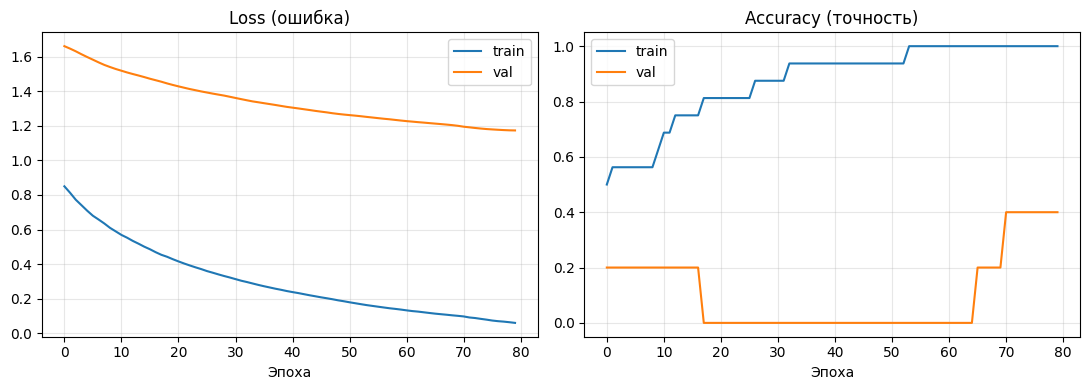

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("Loss (ошибка)")
axes[0].set_xlabel("Эпоха")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history["accuracy"], label="train")
axes[1].plot(history.history["val_accuracy"], label="val")
axes[1].set_title("Accuracy (точность)")
axes[1].set_xlabel("Эпоха")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

---

## Что дальше?

Это рабочий пример. Для сдачи задачи вам нужно:

### На 7 баллов
1. Повторить эти шаги (можно модифицировать данные, архитектуру, параметры)
2. Написать **объяснение в markdown-ячейках**: что делает каждый слой, что такое loss, как работает fit/predict

### На 10 баллов (любые 3 пункта сверху)
- Добавить **Dropout** и **Early Stopping** → объяснить зачем
- Сделать **мультиклассовую** классификацию (3 класса) с `softmax`
- Сравнить **2–3 архитектуры** (разное число слоёв/нейронов) → таблица с метриками
- Реализовать **forward pass на numpy** → показать что результат совпадает с `model.predict()`
- Использовать **Embedding** вместо TF-IDF

Подробнее — в `README.md` и `answer_task2.ipynb`.